In [ ]:
from pathlib import Path
import sys

from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

import numpy as np
import matplotlib.pyplot as plt

from syssimx_examples.controlled_pendulum import MasterPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config

In [ ]:
from syssimx.components.fmu import FMUComponent

PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

In [6]:
set_point = FMUComponent(name="SineAngle",
                         fmu_path=fmu_paths['Trajectories']["SineAngleSetPoint"],
                         group="Controller")

pid = FMUComponent(name="PID",
                   fmu_path=fmu_paths['Controllers']["PIDContinuous_cvode"],
                   group="Controller")
pid.set_parameters(Kd=0.05, Ki=5, Kp=5)

drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']["DriveAdvanced"],
                     group="Actuator")



In [7]:
angle_encoder = FMUComponent(name="Angle Sensor",
                             fmu_path=fmu_paths['Sensors']['AnglePotentiometerADC'],
                             group="Sensor")
angle_decoder = FMUComponent(name="Decoder",
                             fmu_path=fmu_paths['Sensors']['AnglePotentiometerADCDecoder'],
                             group="Controller")

nBits = 8
angle_encoder.set_parameters(nBits=nBits)
angle_decoder.set_parameters(nBits=nBits)

In [8]:
init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = False
sim_params.use_gravity = True

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'mat_params': mat_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU")

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

t     = 0.0
dt    = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [9]:
from syssimx.system.connection import Connection

c1 = Connection(
    src_comp=set_point.name,
    src_port=set_point.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c21 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_encoder.name,
    dst_port=angle_encoder.input_specs["theta"].name,
)

c22 = Connection(
    src_comp=angle_encoder.name,
    src_port=angle_encoder.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c23 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c51 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["phi"].name,
)

c52 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

c53 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["alpha"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["alpha"].name,
)

connections = [c1, c21, c22, c23, c3, c4, c51, c52, c53]
components  = [set_point, pid, drive, pendulum, angle_decoder, angle_encoder]

In [10]:
from syssimx import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

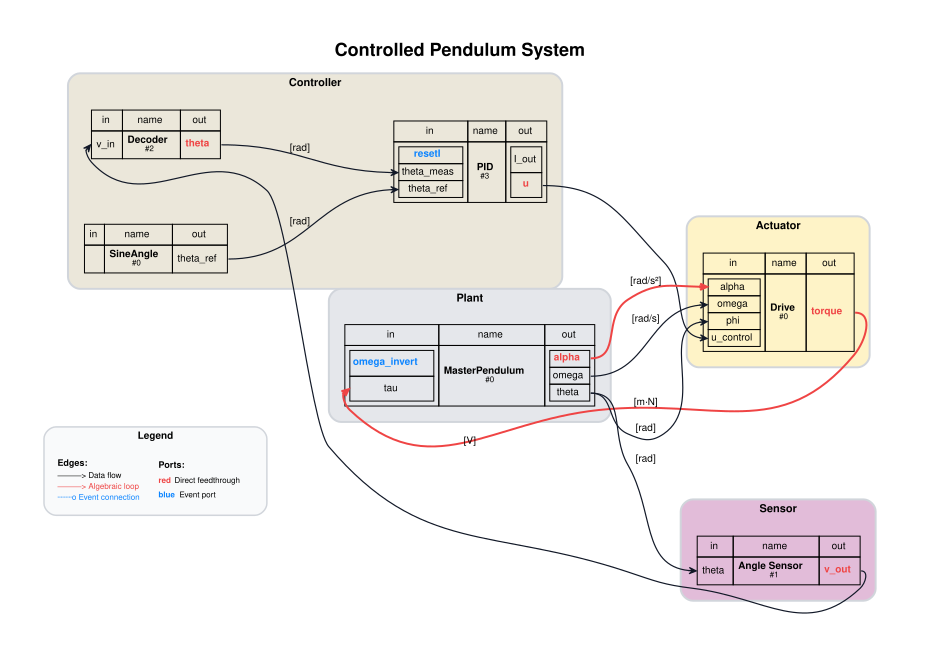

In [11]:
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [12]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [13]:
system.run(t, t_end, dt)

[MasterPendulum] Switching: FMU to FEM @ t=0.0500s
[MasterPendulum] Switching: FEM to OpenSim @ t=0.1100s
[MasterPendulum] Switching: OpenSim to FMU @ t=0.1700s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one

In [14]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
} 
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}

In [15]:
fem_hist = pendulum.fem.get_history()
fmu_hist = pendulum.fmu.get_history()
opensim_hist = pendulum.opensim.get_history()

t_fem = fem_hist['theta']['time']
theta_fem = fem_hist['theta']['values']
t_fmu = fmu_hist['theta']['time']
theta_fmu = fmu_hist['theta']['values']
t_opensim = opensim_hist['theta']['time']
theta_opensim = opensim_hist['theta']['values']

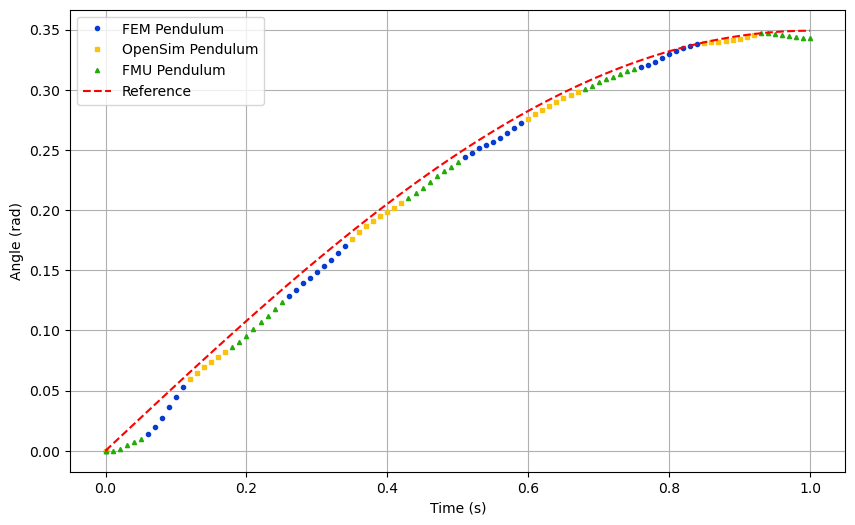

In [16]:
history = system.get_history()

ref_history = history["SineAngle"]
t_ref, data = ref_history
q_ref = data["theta_ref"]

plt.figure(figsize=(10, 6))
plt.plot(t_fem, theta_fem, label="FEM Pendulum", **fem_style)
plt.plot(t_opensim, theta_opensim, label="OpenSim Pendulum", **opensim_style)
plt.plot(t_fmu, theta_fmu, label="FMU Pendulum", **eqb_style)
plt.plot(t_ref, q_ref, label="Reference", color="red", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.legend()
plt.grid()
plt.show()